In [415]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix,accuracy_score,recall_score,precision_score,classification_report,f1_score,root_mean_squared_error,ConfusionMatrixDisplay
import joblib

In [383]:
data = pd.read_csv("Telco-Customer-Churn.csv")

In [405]:
data.Churn.value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [406]:
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [385]:
data = data.drop("customerID", axis=1)

In [386]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [387]:
data.shape

(7043, 20)

In [388]:
data.TotalCharges.unique()

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      dtype=object)

In [389]:
data.TotalCharges.value_counts()

TotalCharges
20.2      11
          11
19.75      9
19.65      8
19.9       8
          ..
1990.5     1
7362.9     1
346.45     1
306.6      1
108.15     1
Name: count, Length: 6531, dtype: int64

In [390]:
data.TotalCharges.count()

np.int64(7043)

In [391]:
data.TotalCharges= pd.to_numeric(data.TotalCharges, errors='coerce')

In [392]:
data.TotalCharges.unique()

array([  29.85, 1889.5 ,  108.15, ...,  346.45,  306.6 , 6844.5 ])

In [393]:
data.isna().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [394]:
data.SeniorCitizen.unique()

array([0, 1])

In [395]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [396]:
num_pipeline = Pipeline([
    ("imputer",SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
cat_pipeline = Pipeline([
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore",sparse_output=False))
])

In [397]:
preprocessor = ColumnTransformer([
                            ("num", num_pipeline, make_column_selector(dtype_include=np.number)),
                            ("cat", cat_pipeline, make_column_selector(dtype_include=object))
])

In [398]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [399]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [400]:
model_pipeline = Pipeline([
                            ("preprocessing", preprocessor),
                            ("model", LogisticRegression())
])

In [401]:
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x00000197C43A83C0>),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x00000197C46953B0>)])),
                ('model', LogisticRegression())])

In [402]:
y_pred_train = model_pipeline.predict(X_train)

In [403]:
accuracy_score(y_train,y_pred_train)

0.8548494983277592

In [404]:
print(classification_report(y_train,y_pred_train))

              precision    recall  f1-score   support

          No       0.88      0.82      0.85      1492
         Yes       0.83      0.89      0.86      1498

    accuracy                           0.85      2990
   macro avg       0.86      0.85      0.85      2990
weighted avg       0.86      0.85      0.85      2990



In [381]:
y_pred_test = model_pipeline.predict(X_test)

C:\Users\Thinkpad\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [410]:
accuracy_score(y_test,y_pred_test)

0.7807486631016043

In [411]:
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

          No       0.81      0.74      0.77       377
         Yes       0.76      0.82      0.79       371

    accuracy                           0.78       748
   macro avg       0.78      0.78      0.78       748
weighted avg       0.78      0.78      0.78       748



In [413]:
confusion_matrix(y_test, y_pred_test)

array([[278,  99],
       [ 65, 306]])

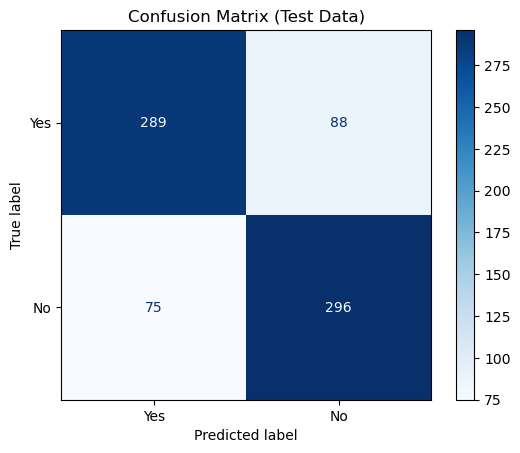

In [425]:
import matplotlib.pyplot as plt
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test), display_labels=['Yes', 'No'])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix (Test Data)")
plt.show()

In [448]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

In [449]:
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x00000197C43A83C0>),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x00000197C46953B0>)])),
                ('model', RandomForestClassifier(random_state=42))])

In [450]:
y_pred_test2 = rf_pipeline.predict(X_test)

C:\Users\Thinkpad\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [451]:
accuracy_score(y_test,y_pred_test2)

0.7820855614973262

In [452]:
print(classification_report(y_test,y_pred_test2))

              precision    recall  f1-score   support

          No       0.79      0.77      0.78       377
         Yes       0.77      0.80      0.78       371

    accuracy                           0.78       748
   macro avg       0.78      0.78      0.78       748
weighted avg       0.78      0.78      0.78       748



In [453]:
confusion_matrix(y_test, y_pred_test2)

array([[289,  88],
       [ 75, 296]])

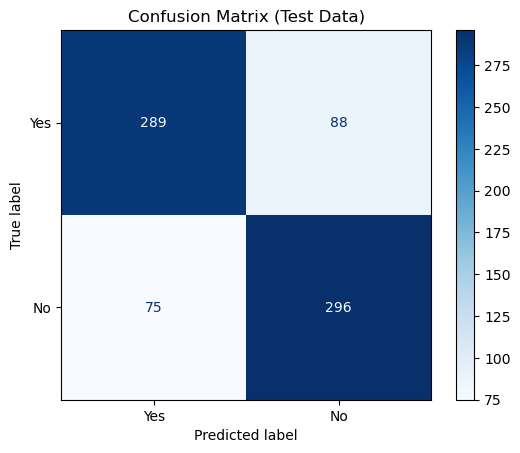

In [454]:
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_test2), display_labels=['Yes', 'No'])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix (Test Data)")
plt.show()

In [455]:
param_grid = {
"model__C":[0.01,0.1,1,10],
"model__solver":["liblinear","lbfgs"]
}

In [456]:
grid_search = GridSearchCV(
    model_pipeline,param_grid,cv=5,scoring="accuracy",n_jobs=-1
)

In [457]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x00000197C43A83C0>),
                                                                        ('cat',
                                                                         Pipeline(steps=[('encoder',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x00000197C46953B0>)])),
                                       ('model', LogisticRegression())]),
             n_jobs=-1,
             param_grid={'model__C': [0.01, 0.1, 1, 10],
                         'model__solver': ['liblinear', 'lbfgs']},
             scoring='accuracy')

In [458]:
grid_search.best_params_

{'model__C': 1, 'model__solver': 'liblinear'}

In [459]:
print(grid_search.best_score_)

0.7665551839464884


In [460]:
best_model = grid_search.best_estimator_

In [461]:
best_pred = best_model.predict(X_test)

C:\Users\Thinkpad\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [462]:
accuracy_score(y_test, best_pred)

0.7807486631016043

In [473]:
confusion_matrix(y_test, best_pred)

array([[278,  99],
       [ 65, 306]])

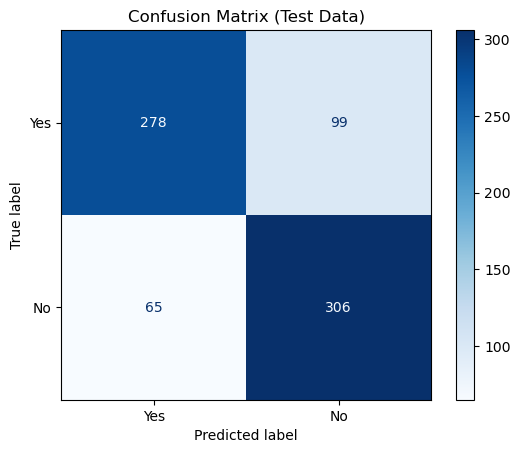

In [474]:
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, best_pred), display_labels=['Yes', 'No'])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix (Test Data)")
plt.show()

In [463]:
rf_param_grid = {
"model__n_estimators":[100,200],
"model__max_depth":[5,10,None],
"model__min_samples_split":[2,5]
}

In [464]:
rf_grid = GridSearchCV(
    rf_pipeline,rf_param_grid,cv=5,scoring="accuracy",n_jobs=-1
)

In [465]:
rf_grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x00000197C43A83C0>),
                                                                        ('cat',
                                                                         Pipeline(steps=[('encoder',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x00000197C46953B0>)])),
                                       ('model',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [5, 10, None],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200]},
             scoring='accuracy')

In [466]:
print(rf_grid.best_params_)
print(rf_grid.best_score_)

{'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 100}
0.7672240802675585


In [467]:
best_rf = rf_grid.best_estimator_

In [469]:
best_rf

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x00000197C95EE930>),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x00000197C9607CB0>)])),
                ('model', RandomForestClassifier(random_state=42))])

In [470]:
joblib.dump(best_rf, "customer_churn_pipeline.pkl")

['customer_churn_pipeline.pkl']

In [471]:
loaded_pipeline = joblib.load("customer_churn_pipeline.pkl")

In [475]:
prediction = loaded_pipeline.predict(X_test.iloc[:8])
print(prediction)

['No' 'No' 'Yes' 'No' 'No' 'Yes' 'Yes' 'Yes']


C:\Users\Thinkpad\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
